In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

Estimated π: 3.14412
True π:      3.141592653589793


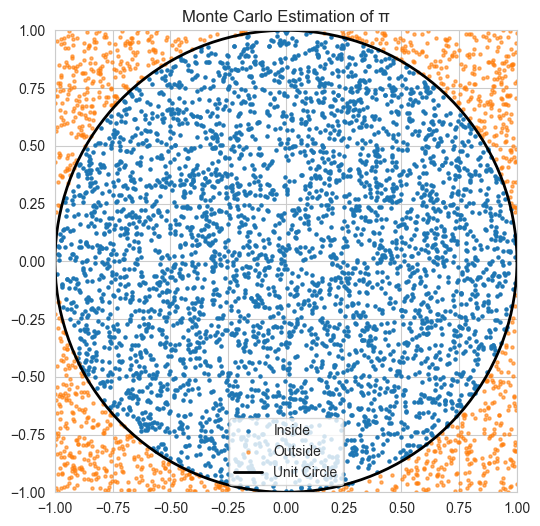

In [2]:
N = 100_000

x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# Check if points are inside the unit circle
inside = (x**2 + y**2 <= 1)
num_inside = np.sum(inside)

pi_estimate = 4 * num_inside / N

print(f"Estimated π: {pi_estimate}")
print(f"True π:      {np.pi}")

#plot of first 5000 points
subset = 5000
x_plot = x[:subset]
y_plot = y[:subset]
inside_plot = inside[:subset]

plt.figure(figsize=(6, 6))

# Plot inside points
plt.scatter(x_plot[inside_plot], y_plot[inside_plot], s=5, label="Inside", alpha=1)

# Plot outside points
plt.scatter(x_plot[~inside_plot], y_plot[~inside_plot], s=5, label="Outside", alpha=0.6)

# Draw unit circle
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), color='black', linewidth=2, label="Unit Circle")

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title("Monte Carlo Estimation of π")
plt.legend()
plt.show()

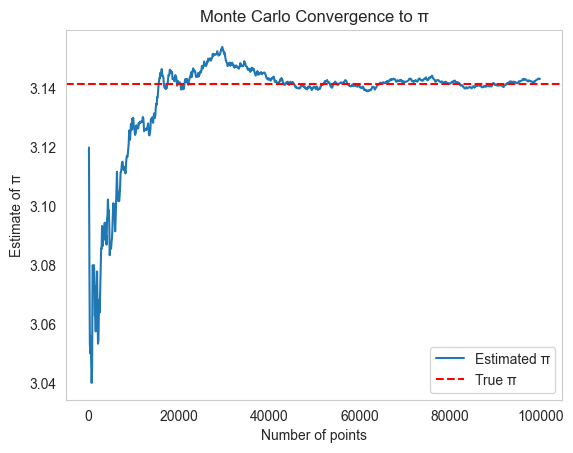

First n where estimate is within ±0.01: 14900


In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

a = []
b = []

for i in range(100, 100_000, 100):
    inside = (x[:i]**2 + y[:i]**2 <= 1)
    num_inside = np.sum(inside)
    pi_estimate = 4 * num_inside / i

    a.append(pi_estimate)
    b.append(i)

plt.plot(b, a, label="Estimated π")

plt.axhline(np.pi, color='red', linestyle='--', label="True π")

plt.xlabel("Number of points")
plt.ylabel("Estimate of π")
plt.title("Monte Carlo Convergence to π")
plt.legend()
plt.grid()

plt.show()
tolerance = 0.01
true_pi = np.pi

stable_n = None
for n, est in zip(b,a):
    if abs(est - true_pi) <= tolerance:
        stable_n = n
        break

print(f"First n where estimate is within ±0.01: {stable_n}")

Firstly it stabilizes around 10000-20000 but it leaves.Mostly it stabilizes around 0.01 after 50000

TASK2

In [4]:
x=np.random.binomial(1, 0.5, size=10000)
print(x.sum()/10000)

0.5021


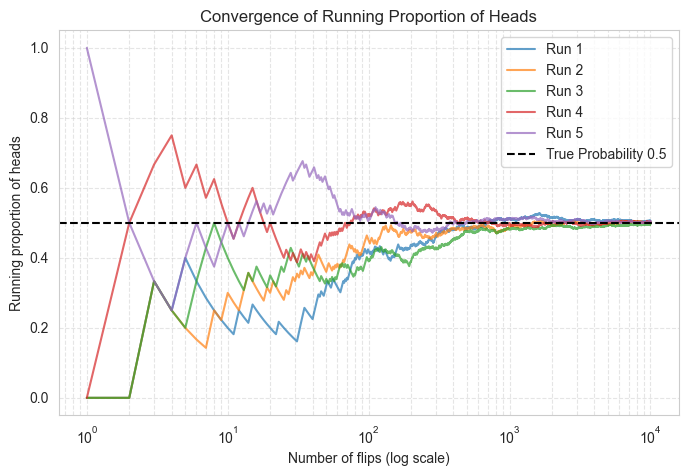

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_flips = 10_000
n_runs = 5
tolerance = 0.01

plt.figure(figsize=(8,5))

for run in range(n_runs):
    # 1=heads, 0=tails
    flips = np.random.binomial(1, 0.5, size=n_flips)

    # Compute running proportion of heads
    cumulative_heads = np.cumsum(flips)
    running_proportion = cumulative_heads / np.arange(1, n_flips+1)

    # Plot convergence
    plt.plot(np.arange(1, n_flips+1), running_proportion, label=f"Run {run+1}", alpha=0.7)

plt.axhline(0.5, color='black', linestyle='--', label="True Probability 0.5")

plt.xscale('log')  # Logarithmic x-axis
plt.xlabel("Number of flips (log scale)")
plt.ylabel("Running proportion of heads")
plt.title("Convergence of Running Proportion of Heads")
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

nearly after 100th flip running proportion stay within ±0.01 of 0.5

TASK3

Empirical vs Theoretical:

P(0 defects):      0.2224 (empirical) vs 0.2181 (theoretical)
P(≥3 defects):     0.1828 (empirical) vs 0.1892 (theoretical)
Expected defects:  1.4751 (empirical) vs 1.5000 (theoretical)


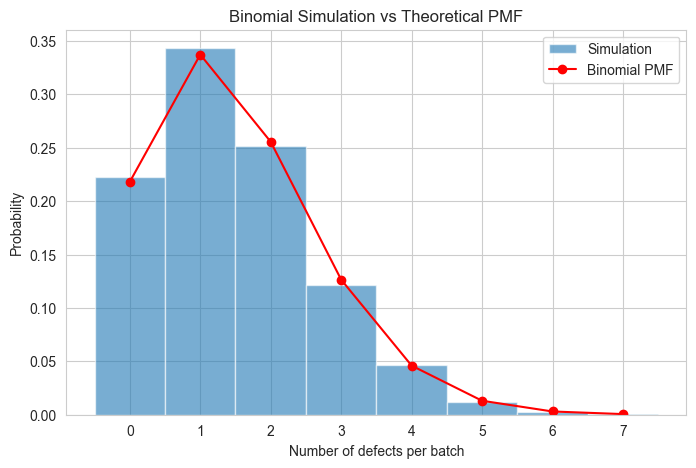

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 50
p = 0.03
batches = 10000

np.random.seed(42)

data = np.random.binomial(n, p, size=batches)

#Empirical estimates
p0_emp = np.mean(data == 0)
p3plus_emp = np.mean(data >= 3)
mean_emp = np.mean(data)

# Theoretical values
p0_th = binom.pmf(0, n, p)
p3plus_th = 1 - binom.cdf(2, n, p)
mean_th = n * p

print("Empirical vs Theoretical:\n")

print(f"P(0 defects):      {p0_emp:.4f} (empirical) vs {p0_th:.4f} (theoretical)")
print(f"P(≥3 defects):     {p3plus_emp:.4f} (empirical) vs {p3plus_th:.4f} (theoretical)")
print(f"Expected defects:  {mean_emp:.4f} (empirical) vs {mean_th:.4f} (theoretical)")

# Plot histogram 
counts = np.arange(0, max(data)+1)

plt.figure(figsize=(8,5))
plt.hist(data, bins=np.arange(-0.5, max(data)+1.5, 1), density=True, alpha=0.6, label="Simulation")

# Overlay Binomial PMF
pmf_vals = binom.pmf(counts, n, p)
plt.plot(counts, pmf_vals, 'o-', color='red', label="Binomial PMF")

plt.xlabel("Number of defects per batch")
plt.ylabel("Probability")
plt.title("Binomial Simulation vs Theoretical PMF")
plt.legend()
plt.grid(True)
plt.show()

For P(0 defects), the empirical value is 0.2224 compared to the theoretical value of 0.2181, a difference of about 0.0043.
For P(≥3 defects), the empirical value is 0.1828 versus 0.1892, a difference of about 0.0064.
For the expected number of defects, the empirical mean is 1.4751 compared to the theoretical value of 1.5, a difference of about 0.025.

All of these differences are small and within the range expected from random sampling variation, indicating that the simulation closely matches the binomial model.

Using 10,000 batches provides high accuracy and stable estimates. If only 1,000 batches were used, the results would still be reasonable but more variable, with larger deviations (around 0.01 to 0.03) and a less smooth histogram.
1,000 batches would be sufficient for a rough approximation, but 10,000 batches are preferable for more precise and reliable estimates.